dataset - https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
# EXPLORATORY DATA ANALYSIS (DIABETES DATASET)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.ensemble import RandomForestClassifier

lets start by importing the dataset and then lets have a look on the columns to understand the data,

In [3]:
diabetes_df = pd.read_csv('/home/spandan/Documents/ML/disease-predictor/data/diabetes.csv')
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


alr lets have look at the columns to get a brief blueprint over the dataset

In [4]:
diabetes_df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

### what are we actually looking at?
seeing the column names is one thing, but we need to know what they actually represent to make any sense of the correlations later. Let's list them out based on the dataset documentation.

#### lets break down and understand the columns first (Given)
1. pregnencies - number of times pregnent
2. Glucose - plasma glucose concentration for a glucose tolorence test
3. BloodPressure - Diastolic Blood Pressure (mm hg)
4. skinThickness - Tricep skin fold thickness (mm)
5. Insulin - 2hr serem insulin
6. BMI - body mass index in kg/m sq
7. DiabetesPedigreeFunction
8. Age
9. Outcomes ( Target Varlaiable ) -- 1 means positive , 0 means negetive for diabetes

In [5]:
diabetes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
diabetes_df['Outcome'].value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

alr , lets check if the dataset contains nulls or 0s for columns which do care for 0s , we will mostly skil the pregnencies , outcomes .

In [8]:
diabetes_df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
(diabetes_df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

here i can see 0s in impossible fields , like glucose can never be zero and if we keep it as it is it will harm the training. similarly for *blood pressure , skinThickness , insulin , BMI*

lets fix the columns ,
common ways to fix include by mean or by median . If we use mean that might get risky for the outliers tho , soo considering a safer option let us replace the 0s with median.
alr let me make a list containing all the cols which needs to be fixed

In [10]:
cols_for_fixing = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

soo pandas is good with handeling NaN values so lets first repace the zeroes with NaN and then we fill them with median

In [11]:
diabetes_df[cols_for_fixing] = diabetes_df[cols_for_fixing].replace(0 , np.nan)
diabetes_df.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [12]:
(diabetes_df == 0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

### checking my work
just double checking here—the NaNs should have replaced those impossible zeros in our target columns. pregnancies and outcome can stay zero, obviously, but the rest look much cleaner now. time to fill those gaps.

alr that did work , lets fill those with median now.

In [13]:
for col in cols_for_fixing:
    median = diabetes_df[col].median()
    diabetes_df[col] = diabetes_df[col].fillna(median)

diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


the missing values are now handled , next lets vizualize the important features using a heatmap !
## corelation heatmap


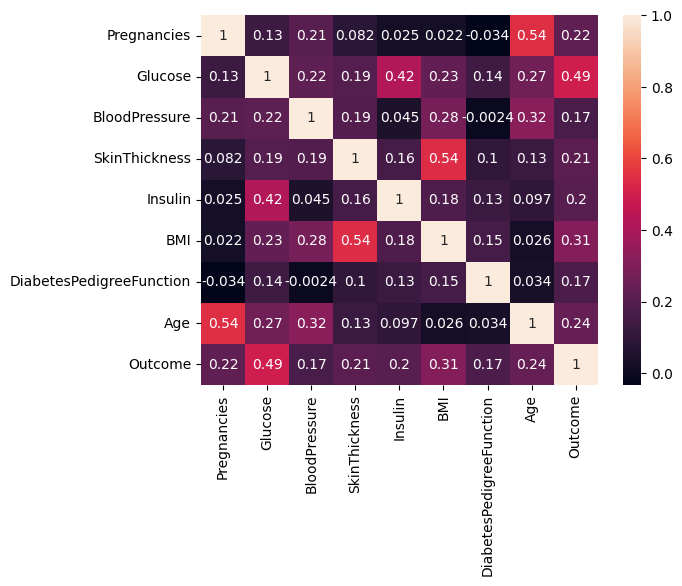

In [14]:
plt.Figure(figsize=(10,8))
sns.heatmap(diabetes_df.corr(), annot=True)
plt.show()

### taking a moment to digest this
okay, looking at that heatmap, the Glucose vs Outcome relationship is screaming at us. it's clearly the heavy hitter here. also, that Age vs Pregnancies link is something we should keep an eye on before we feed this into a linear model.

>the heatmap seems a lot more informative than the dataset
so , we can notice the strongest positive relation wrt
1. Gluecose (thats just directly proportional)
2. BMI , makes sense , in real world senarios as well.

what i can notice is there is multicoliniarity  (string relation between features) at age vs pregnencies (makes sense) , and BMI vs Skin thickness. this can harml logistic regression . still to consider for comparison , lets start with a logistic regreesion Model.

# Logistic Regression
>we are already clear with the dependent and independent vars , Outcome is a dependent var  and rest , lets just take them in y

In [15]:
x = diabetes_df.drop('Outcome' , axis = 1)
y = diabetes_df['Outcome']

In [16]:
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47


In [17]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

alr then lets split the data for train and test by 80/20 proportion , once done we can move towards scaling

In [18]:
x_train , x_test , y_train , y_test = train_test_split(x , y , random_state=42 , test_size=0.2)

In [19]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

### training time
scales are set, data is split. let's see how the baseline logistic regression handles this. i'm curious to see if it catches the patterns or gets tripped up by the noise.

In [20]:
lr_model = LogisticRegression()
lr_model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
lr_pred = lr_model.predict(x_test)

In [22]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82        99
           1       0.69      0.62      0.65        55

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



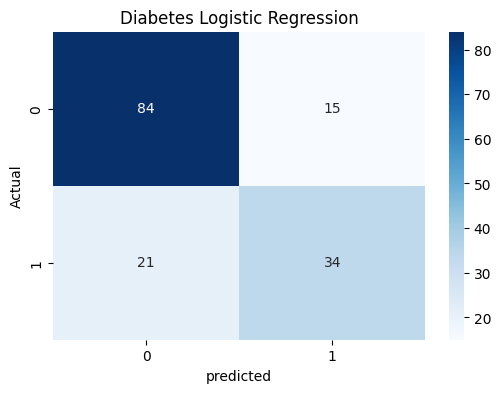

In [23]:
cm = confusion_matrix(y_test , lr_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm , annot=True  , cmap = 'Blues')

plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Diabetes Logistic Regression")

plt.show()

### Conclusion from Logistic Regression

The Logistic Regression model gave an accuracy of around 77%, which is decent for a medical dataset like this. The model was able to predict non-diabetic patients fairly well, but struggled comparatively more while detecting diabetic patients.

One important observation here is that the recall for diabetic cases is lower than desired. This means the model is still missing a noticeable number of actual diabetic patients (false negatives), which can be risky in real-world medical scenarios.

Another interesting thing noticed during this process was how important preprocessing actually is. Initially, the dataset appeared to have no missing values, but several columns contained medically impossible zeros which were acting as hidden missing values. Replacing them using median imputation improved the dataset quality and made the model training more reliable.

Overall, Logistic Regression works as a solid baseline model for this dataset, but there is still room for improvement using more advanced models like Random Forest.


# Random Forest Classifier

In [24]:
rf_model = RandomForestClassifier(random_state=42 , n_estimators=299)
rf_model.fit(x_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",299
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
rf_pred = rf_model.predict(x_test)

In [26]:
print(classification_report(y_test , rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        99
           1       0.67      0.67      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [27]:
rf_cm = confusion_matrix(y_test , rf_pred)

### how did the forest do?
let's visualize the confusion matrix for the Random Forest. usually, these ensemble models are better at picking up the nuances that simple regression might miss, especially with features like BMI and Insulin acting together.

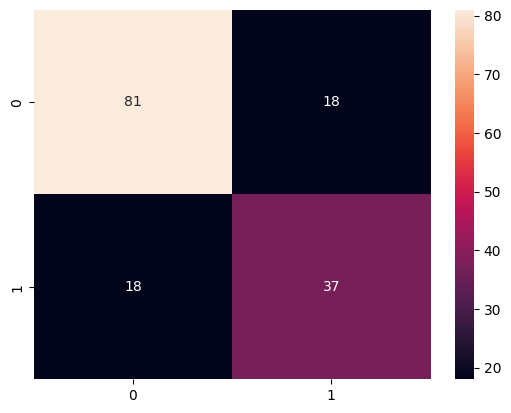

In [28]:
sns.heatmap(rf_cm , annot=True)
plt.show()

In [29]:
importance = pd.DataFrame({
    "features" : x.columns,
    "importance" : rf_model.feature_importances_
})

importance = importance.sort_values(by = "importance" , ascending=False)

print(importance)

                   features  importance
1                   Glucose    0.256770
5                       BMI    0.165276
7                       Age    0.139238
6  DiabetesPedigreeFunction    0.119710
4                   Insulin    0.092145
2             BloodPressure    0.082466
0               Pregnancies    0.072932
3             SkinThickness    0.071462


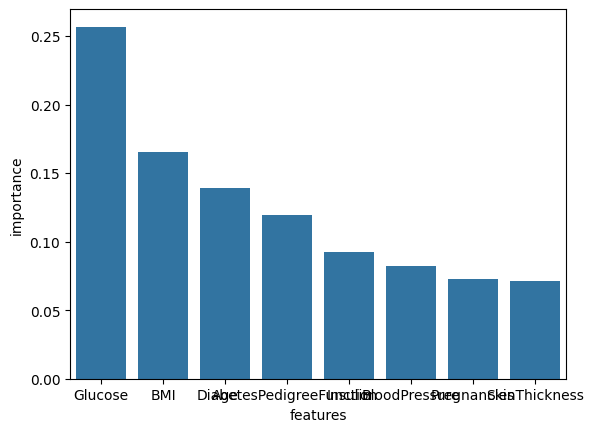

In [30]:
sns.barplot(x = importance['features'] , y = importance['importance'] , data = importance)
plt.show('feature importance')
plt.show()

This dataset was honestly more realistic than the heart disease one. At first it looked clean because there were no null values, but later we found out that many columns had impossible zeros acting as hidden missing values. After handling them using median imputation, the dataset became much cleaner for training.

From the heatmap and feature importance graph, Glucose turned out to be the most important feature for predicting diabetes, followed by BMI and Age. Logistic Regression gave decent baseline performance, while Random Forest slightly improved recall by catching more diabetic patients.

Overall this notebook helped in understanding:

preprocessing and missing value handling
correlation and multicollinearity
Logistic Regression vs Random Forest
confusion matrix and classification metrics
feature importance in tree based models

Compared to the heart dataset, this one felt more noisy and challenging, which made the workflow feel much closer to real world ML problems.

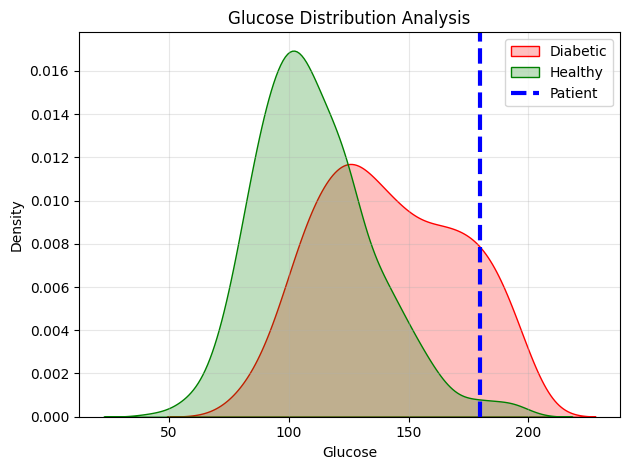

In [ ]:
patient_glucose = 180
plt.Figure(figsize=(10,6))
sns.kdeplot(
    data = diabetes_df[diabetes_df['Outcome'] == 1],
    x = 'Glucose',
    color = 'red',
    fill = True,
    label = 'Diabetic'
)
sns.kdeplot(
    data = diabetes_df[diabetes_df['Outcome'] == 0 ],
    x = 'Glucose',
    color = 'green',
    label = 'Healthy',
    fill = True
)
plt.axvline(
    patient_glucose,
    linestyle='--',
    linewidth=3,
    label='Patient',
    color = 'blue'
)
plt.title('Glucose Distribution Analysis')
plt.xlabel('Glucose')
plt.ylabel('Density')
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()


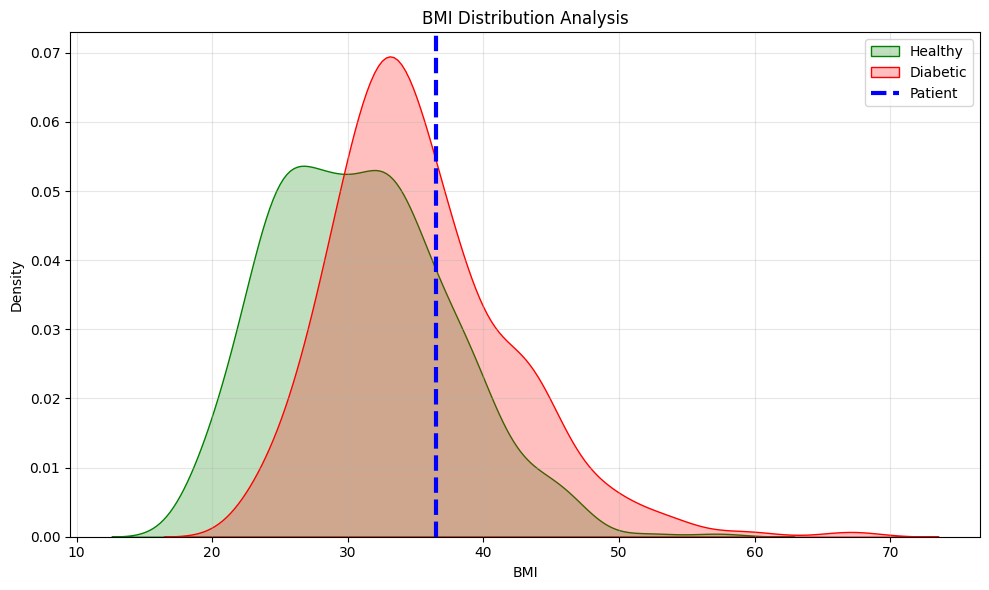

In [36]:
plt.figure(figsize=(10,6))

patient_bmi = 36.5

sns.kdeplot(
    data = diabetes_df[diabetes_df['Outcome'] == 0],
    x = 'BMI',
    fill = True,
    color = 'green',
    label = 'Healthy'
)

sns.kdeplot(
    data = diabetes_df[diabetes_df['Outcome'] == 1],
    x = 'BMI',
    fill = True,
    color = 'red',
    label = 'Diabetic'
)

plt.axvline(
    patient_bmi,
    color = 'blue',
    linestyle = '--',
    linewidth = 3,
    label = 'Patient'
)

plt.title('BMI Distribution Analysis')

plt.xlabel('BMI')

plt.ylabel('Density')

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

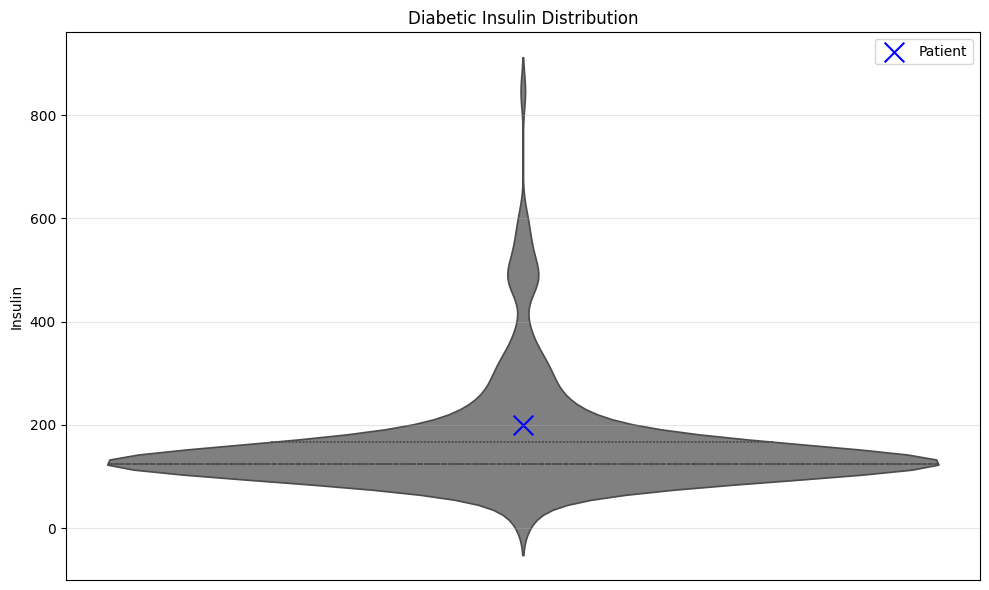

In [51]:
plt.figure(figsize=(10,6))

patient_insulin = 200

sns.violinplot(
    data = diabetes_df[diabetes_df['Outcome'] == 1],
    y = 'Insulin',
    color = 'gray',
    inner = 'quartile'
)

plt.scatter(
    0,
    patient_insulin,
    color = 'blue',
    marker = 'x',
    s = 200,
    label = 'Patient'
)

plt.title('Diabetic Insulin Distribution')

plt.ylabel('Insulin')

plt.xticks([])

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [52]:
from sklearn.preprocessing import MinMaxScaler

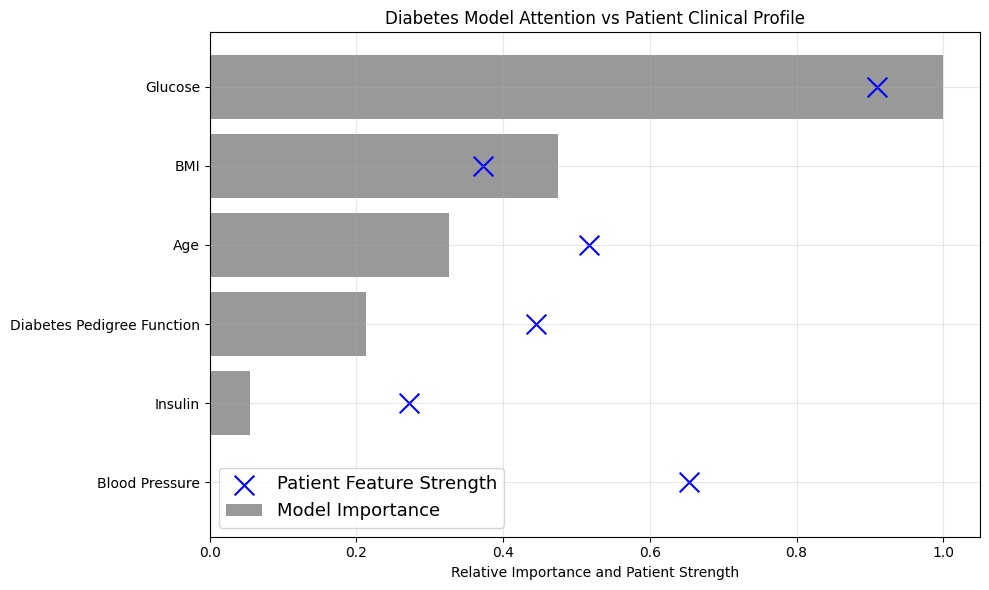

In [58]:
features = [
    'Glucose',
    'BMI',
    'Age',
    'DiabetesPedigreeFunction',
    'Insulin',
    'BloodPressure'
]
feature_display_names = [
    'Glucose',
    'BMI',
    'Age',
    'Diabetes Pedigree Function',
    'Insulin',
    'Blood Pressure'
]
importances = [
    0.256770,
    0.165276,
    0.139238,
    0.119710,
    0.092145,
    0.082466
]
patient_values = {
    'Glucose': 185,
    'BMI': 36.4,
    'Age': 52,
    'DiabetesPedigreeFunction': 1.12,
    'Insulin': 240,
    'BloodPressure': 88
}
patient_df = pd.DataFrame([patient_values])
patient_Scaler = MinMaxScaler()
patient_Scaler.fit(diabetes_df[features])
normalized_patients  = patient_Scaler.transform(patient_df).flatten()
normalized_patients=np.clip(normalized_patients , 0 , 1)

important_scaler = MinMaxScaler()
normalized_coefficients = important_scaler.fit_transform(
    np.array(importances).reshape(-1,1)
).flatten()

plt.figure(figsize=(10,6))

sns.barplot(
    x = normalized_coefficients,
    y = feature_display_names,
    color = 'gray',
    alpha = 0.8,
    label = 'Model Importance'
)

plt.scatter(
    normalized_patients,
    feature_display_names,
    color = 'blue',
    marker = 'x',
    s = 200,
    label = 'Patient Feature Strength'
)

plt.xlim(0,1.05)

plt.xlabel('Relative Importance and Patient Strength')

plt.title('Diabetes Model Attention vs Patient Clinical Profile')

plt.legend(fontsize = 13)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

